In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv(r"C:\Users\HP\Downloads\day.csv")
df = pd.read_csv(r"C:\Users\HP\Downloads\hour.csv")

In [4]:
print("First 5 rows of data:")
print(df.head())

First 5 rows of data:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [5]:
#Understand the data
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


In [6]:
print(df.describe())

          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.496987   
std        0.167165      2.005771      0.465431      0.639357      0.

In [7]:
#Checking the missing values
print(df.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [8]:
df = df.drop(['instant', 'dteday'], axis=1)

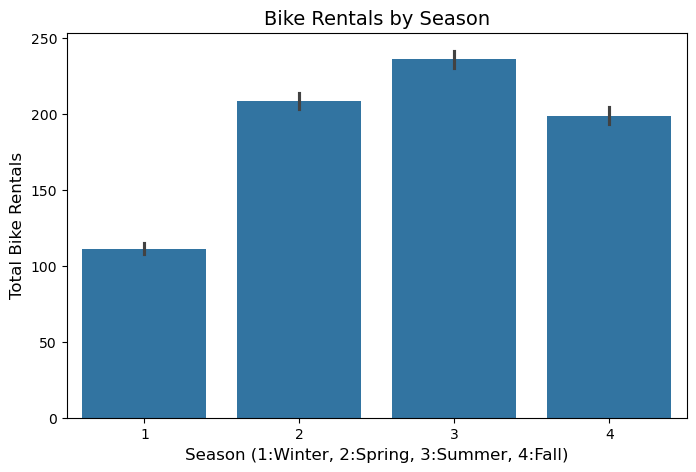

In [9]:
#Exploratory Data Analysis (EDA)
# 1. Rentals vs Season
plt.figure(figsize=(8,5))
sns.barplot(
    x='season',
    y='cnt',
    data=df)
plt.title("Bike Rentals by Season", fontsize=14)
plt.xlabel("Season (1:Winter, 2:Spring, 3:Summer, 4:Fall)", fontsize=12)
plt.ylabel("Total Bike Rentals", fontsize=12)
plt.show()

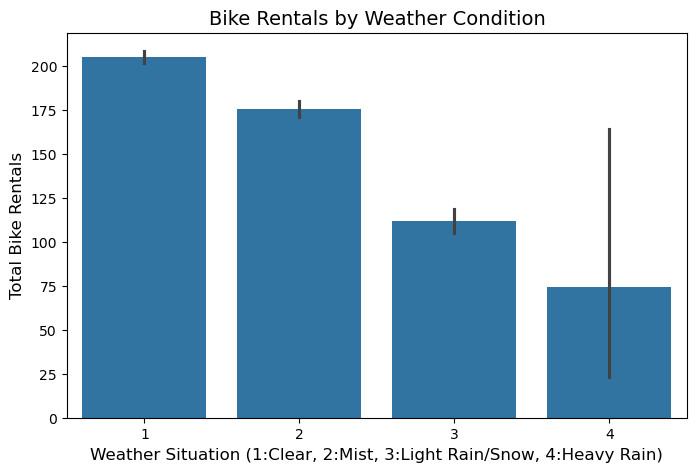

In [10]:
# 2. Rentals vs Weather
plt.figure(figsize=(8,5))
sns.barplot(
    x='weathersit',
    y='cnt',
    data=df)
plt.title("Bike Rentals by Weather Condition", fontsize=14)
plt.xlabel("Weather Situation (1:Clear, 2:Mist, 3:Light Rain/Snow, 4:Heavy Rain)", fontsize=12)
plt.ylabel("Total Bike Rentals", fontsize=12)
plt.show()

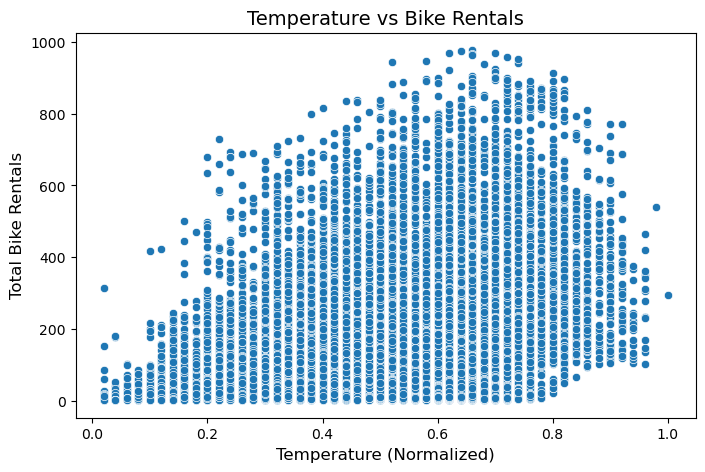

In [11]:
# 3. Temperature vs Rentals
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='temp',
    y='cnt',
    data=df)
plt.title("Temperature vs Bike Rentals", fontsize=14)
plt.xlabel("Temperature (Normalized)", fontsize=12)
plt.ylabel("Total Bike Rentals", fontsize=12)
plt.show()

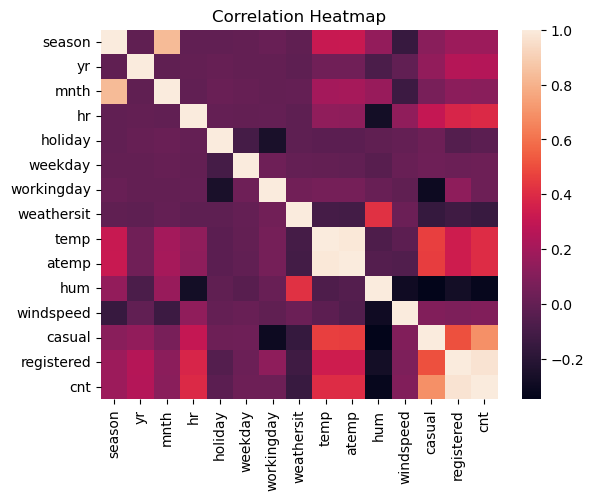

In [12]:
# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [13]:
#Feature Selection
X = df.drop('cnt', axis=1)
y = df['cnt']

In [14]:
X.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1


In [15]:
y.head()

0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64

In [16]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
#Model Building
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
#Model Evaluation
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"\n{name} Results:")
    print("R2 Score:", round(r2, 3))
    print("MSE:", round(mse, 3))
    return r2, mse

lr_results = evaluate_model(lr_model, "Linear Regression")
dt_results = evaluate_model(dt_model, "Decision Tree")
rf_results = evaluate_model(rf_model, "Random Forest")


Linear Regression Results:
R2 Score: 1.0
MSE: 0.0

Decision Tree Results:
R2 Score: 0.999
MSE: 22.978

Random Forest Results:
R2 Score: 1.0
MSE: 7.414


In [23]:
#Model comparison
print("\nFinal Comparison:")
print("Decision Tree R2:", r2_score(y_test, pred_best_dt))
print("Random Forest R2:", r2_score(y_test, pred_best_rf))



Final Comparison:
Decision Tree R2: 0.9991979492858949
Random Forest R2: 0.999775901318568


In [20]:
# Hyperparameter Tuning (Decision Tree)
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Hyperparameter Tuning (Decision Tree)
print("\nTuning Decision Tree...")

params_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeRegressor(), params_dt, cv=5)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
pred_best_dt = best_dt.predict(X_test)
print("Best Parameters:", grid_dt.best_params_)
print("Tuned R2:", r2_score(y_test, pred_best_dt))


Tuning Decision Tree...
Best Parameters: {'max_depth': None, 'min_samples_split': 5}
Tuned R2: 0.9991979492858949


In [21]:
# Hyperparameter Tuning (Random Forest)
print("\nTuning Random Forest...")

params_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]}
grid_rf = GridSearchCV(RandomForestRegressor(), params_rf, cv=5)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
pred_best_rf = best_rf.predict(X_test)
print("Best Parameters:", grid_rf.best_params_)
print("Tuned R2:", r2_score(y_test, pred_best_rf))


Tuning Random Forest...
Best Parameters: {'max_depth': None, 'n_estimators': 100}
Tuned R2: 0.999775901318568


In [25]:
#Important Note
print("\nNote:")
print("Confusion Matrix is not used because this is a regression problem, not classification.")


Note:
Confusion Matrix is not used because this is a regression problem, not classification.


In [ ]:
1.Model Comparison

In this project, three different models were used to predict the number of bike rentals: Linear Regression, Decision Tree, and Random Forest.
Linear Regression was used as a basic model, but it gave low accuracy because it could not capture complex patterns in the data. Decision Tree
performed much better as it can handle non-linear relationships, and it showed a significant improvement in results.Random Forest gave the best
performance among all models.Since it is an ensemble model (combination of multiple decision trees), it was able to make more accurate and stable
predictions.Overall, Random Forest had the highest R² score and lowest error, making it the best model.

2. Challenges Faced

While working on this project, I faced a few challenges.First, understanding the dataset was a bit confusing, especially the meaning of some features.
Then, selecting the right features was important.Columns like instant and dteday were not useful, so they had to be removed.Another major challenge was avoiding data leakage. The columns casual and registered
directly contribute to the target variable cnt, so keeping them would give incorrect high accuracy. Hence, they were removed.There was also an issue of
multicollinearity, as atemp was very similar to temp, so it was dropped.Finally, choosing the right model and tuning it using GridSearch took some
effort, but it helped improve the model performance.

3. Conclusion

From the overall analysis and model comparison, Random Forest turned out to be the best model for this project. It gave the highest accuracy and 
handled the data more effectively compared to other models.It was able to capture complex patterns and provide better predictions for bike rental
demand.Therefore, Random Forest is selected as the final model for this project and can be used for real-world prediction of bike rentals.